In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Load data
decon = pd.read_csv("Decon-Results_Loy_Inflammatory-Syndromes/merged_normalised_results.txt", sep="\t", index_col=0)
meta = pd.read_csv("meta_ALT.csv")

# Clean sample IDs
meta["sample_id_clean"] = meta["sample_id"].str.replace("_trimmed", "", regex=False)
decon = decon.reset_index().rename(columns={"index": "sample_id"})

# Merge
merged = pd.merge(decon, meta, left_on="sample_id", right_on="sample_id_clean")

# Report matched sample count
print(f"Total matched rows (sample x tool): {merged.shape[0]}")
print(f"Unique matched samples: {merged['sample_id_clean'].nunique()}")

results = []
for tool, df_tool in merged.groupby("DeconvolutionTool"):
    liver = df_tool["Liver"].astype(float)
    alt = df_tool["palt"].astype(float)

    # Spearman correlation
    rho, pval_rho = spearmanr(liver, alt)

    # Pearson correlation after log transform
    alt_log = np.log1p(alt)
    r, pval_r = pearsonr(liver, alt_log)

    results.append({
        "DeconvolutionTool": tool,
        "Spearman_rho": rho,
        "Spearman_p": pval_rho,
        "Pearson_r_logALT": r,
        "Pearson_p": pval_r
    })

    # --- Plot with linear ALT axis ---
    plt.figure(figsize=(3, 3))
    sns.set(style="white")
    sns.set_context("paper", font_scale=1.0)

    ax = sns.regplot(
        x=alt, 
        y=liver,
        scatter_kws={'s': 10, 'alpha': 0.4, 'color': 'black'},
        line_kws={'color': 'crimson', 'lw': 2}
    )

    ax.set_xlabel('ALT (U/L)', fontsize=10)
    ax.set_ylabel('Liver contribution (%)', fontsize=10)
    ax.set_title(f'Liver vs ALT ({tool}) \nSpearman rho={rho:.2f}, p={pval_rho:.2e}', 
                 fontsize=13)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"ALT_vs_Liver_{tool}_linear.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"ALT_vs_Liver_{tool}_linear.pdf", dpi=300, bbox_inches="tight")
    plt.close()

    # --- Plot with log ALT axis ---
    plt.figure(figsize=(3, 3))
    sns.set(style="white")
    sns.set_context("paper", font_scale=1.0)

    ax = sns.regplot(
        x=alt, 
        y=liver,
        scatter_kws={'s': 30, 'alpha': 0.4, 'color': 'black'},
        line_kws={'color': 'crimson', 'lw': 2}
    )

    ax.set_xscale("log")
    ax.set_xlabel('ALT (U/L, log scale)', fontsize=10)
    ax.set_ylabel('Liver contribution (%)', fontsize=10)
    ax.set_title(f'Liver vs ALT ({tool}) \nSpearman rho={rho:.2f}, p={pval_rho:.2e}', 
                 fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"ALT_vs_Liver_{tool}_log.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"ALT_vs_Liver_{tool}_log.pdf", dpi=600, bbox_inches="tight")
    plt.close()


# Save correlation summary
summary = pd.DataFrame(results)
summary.to_csv("ALT_Liver_correlations.csv", index=False)
print(summary)


Total matched rows (sample x tool): 252
Unique matched samples: 36
  DeconvolutionTool  Spearman_rho  Spearman_p  Pearson_r_logALT  Pearson_p
0        BayesPrism      0.647558    0.000020          0.642625   0.000024
1        CIBERSORTx      0.629729    0.000039          0.609326   0.000080
2             MuSiC      0.625604    0.000045          0.434103   0.008162
3              NNLS      0.485705    0.002674          0.512445   0.001397
4                QP      0.163784    0.339836          0.346783   0.038260
5          ReDeconv      0.561983    0.000361          0.576237   0.000235
6             nuSVR      0.219748    0.197827          0.441322   0.007052


Matched unique samples: 36
Matched rows (sample × tool): 252

Statistical results per tool:
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.000066  0.000230         True
1             MuSiC  0.000239  0.000558         True
2             nuSVR  0.151390  0.176621        False
3        CIBERSORTx  0.000016  0.000113         True
4              NNLS  0.001508  0.002639         True
5                QP  0.285547  0.285547        False
6          ReDeconv  0.006720  0.009409         True


/tmp/ipykernel_1447027/3192385616.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for tool, df_tool in merged.groupby("DeconvolutionTool"):


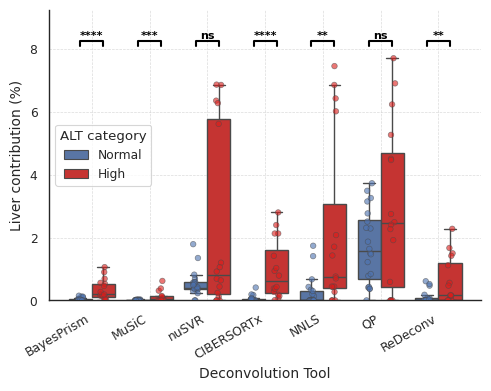

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ---------- Helper functions ----------
def pval_to_star(p):
    """Convert p-value to significance stars."""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# Color palette for categories
palette = {"Normal": "#4C72B0", "High": "#DD1C1A"}
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]

# ---------- File paths (update as needed) ----------
decon_file = "Decon-Results_Loy_Inflammatory-Syndromes/merged_normalised_results.txt"
meta_file  = "meta_ALT.csv"

# ---------- Load data ----------
decon = pd.read_csv(decon_file, sep="\t", index_col=0)
meta = pd.read_csv(meta_file)

# Clean sample IDs
meta["sample_id_clean"] = meta["sample_id"].str.replace("_trimmed", "", regex=False)
decon = decon.reset_index().rename(columns={"index": "sample_id"})

# Merge
merged = pd.merge(decon, meta, left_on="sample_id", right_on="sample_id_clean")
# Enforce plotting order for tools
merged["DeconvolutionTool"] = pd.Categorical(
    merged["DeconvolutionTool"],
    categories=tool_order,
    ordered=True
)
merged = merged.sort_values("DeconvolutionTool")

# Ensure numeric
merged["Liver"] = pd.to_numeric(merged["Liver"], errors="coerce")
merged["palt"]  = pd.to_numeric(merged["palt"], errors="coerce")
merged = merged.dropna(subset=["Liver", "palt"])

# Define ALT categories
merged["ALT_category"] = pd.Series(pd.NA, index=merged.index)
merged.loc[merged["palt"] < 40, "ALT_category"] = "Normal"
merged.loc[merged["palt"] > 100, "ALT_category"] = "High"
merged = merged.dropna(subset=["ALT_category"])

print(f"Matched unique samples: {merged['sample_id_clean'].nunique()}")
print(f"Matched rows (sample × tool): {merged.shape[0]}")

# ---------- Statistical tests ----------
results = []
for tool, df_tool in merged.groupby("DeconvolutionTool"):
    groups = df_tool.groupby("ALT_category")["Liver"].apply(list)
    if set(groups.keys()) == {"Normal", "High"}:
        stat, pval = mannwhitneyu(groups["Normal"], groups["High"], alternative="two-sided")
        results.append({"DeconvolutionTool": tool, "pval": pval})

results_df = pd.DataFrame(results)

# Adjust with BH correction
reject, pvals_corrected, _, _ = multipletests(results_df["pval"], method="fdr_bh")
results_df["BH_adj_p"] = pvals_corrected
results_df["Significant"] = reject

print("\nStatistical results per tool:")
print(results_df)

# ---------- Plot ----------
plt.figure(figsize=(5, 4))
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.0)

# Desired order for legend and plotting
hue_order = ["Normal", "High"]

# Boxplot + jittered stripplot overlay
ax = sns.boxplot(
    data=merged,
    x="DeconvolutionTool",
    y="Liver",
    hue="ALT_category",
    hue_order=hue_order,
    order=tool_order,
    palette=palette,
    dodge=True,
    showfliers=False
)

sns.stripplot(
    data=merged,
    x="DeconvolutionTool",
    y="Liver",
    hue="ALT_category",
    hue_order=hue_order,
    order=tool_order,
    palette=palette,
    dodge=True,
    jitter=True,
    alpha=0.6,
    linewidth=0.5,
    size=4
)

# Remove duplicate legend from stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="ALT category")

# Get tool positions
xticks = ax.get_xticks()
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
tool_to_x = dict(zip(xticklabels, xticks))

ymax = merged["Liver"].max()

# Function to draw bracket + stars
def add_bracket(ax, x1, x2, y, text, height=0.05):
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.5, c='black')
    ax.text((x1+x2)/2, y+height, text, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color='black')

# Annotate each tool with bracket + stars
for _, row in results_df.iterrows():
    tool = row["DeconvolutionTool"]
    if tool in tool_to_x:
        x = tool_to_x[tool]
        #pval = row["BH_adj_p"]
        pval = row["pval"]
        label = pval_to_star(pval)

        # Bracket between the two boxplots (Normal vs High)
        # With dodge=True, groups are offset left/right around `x`
        offset = 0.2
        x1, x2 = x - offset, x + offset
        y = ymax * 1.05  # baseline height
        add_bracket(ax, x1, x2, y, label, height=ymax * 0.02)

ax.set_xlabel("Deconvolution Tool", fontsize=10)
ax.set_ylabel("Liver contribution (%)", fontsize=10)
ax.set_ylim(0, ymax * 1.2)  # leave room for brackets
#ax.set_title("Liver contribution vs ALT category across tools",
#             fontsize=12)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("ALT_category_vs_Liver_Loy_Inflammatory.svg", format="svg", bbox_inches="tight")
plt.show()

# ---------- Save results ----------
results_df.to_csv("ALT_category_vs_Liver_stats.csv", index=False)
